# VeriTriage — SHAP Interpretability Analysis
## Notebook 05: Which Placement Features Drive Sign-Off Failures?

**Author:** Tushar Dudeja  
**Project:** VeriTriage — ML-Based Sign-Off Verification Triage

---

### Objective
Use SHAP to explain model predictions — giving engineers actionable
insight into which placement decisions cause IR drop, DRC, and congestion failures.

## 1. Imports and Setup

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

ROOT = Path(r"C:\Users\TUSHAR\2026-27\PROJECTS\VeriTriage")

df = pd.read_csv(ROOT / "data/processed/veritriage_features.csv")
FEATURE_COLS = [c for c in df.columns if c.startswith('cd_') or c.startswith('mr_')]

models = {
    'IR Drop':    joblib.load(ROOT / "models/label_ir_xgb.pkl"),
    'DRC':        joblib.load(ROOT / "models/label_drc_xgb.pkl"),
    'Congestion': joblib.load(ROOT / "models/label_cg_xgb.pkl"),
}

feature_names = [f.replace('cd_', 'CellDensity_')
                  .replace('mr_', 'MacroRegion_')
                  for f in FEATURE_COLS]

X = df[FEATURE_COLS].values

print(f"Dataset:      {len(df)} samples")
print(f"Features:     {len(FEATURE_COLS)}")
print(f"Models:       {list(models.keys())}")
print(f"SHAP version: {shap.__version__}")

Dataset:      10242 samples
Features:     42
Models:       ['IR Drop', 'DRC', 'Congestion']
SHAP version: 0.49.1


## 2. SHAP Feature Importance — All 3 Tasks

Computing SHAP for IR Drop...
  Top feature: CellDensity_kurtosis
Computing SHAP for DRC...
  Top feature: CellDensity_skewness
Computing SHAP for Congestion...
  Top feature: CellDensity_kurtosis


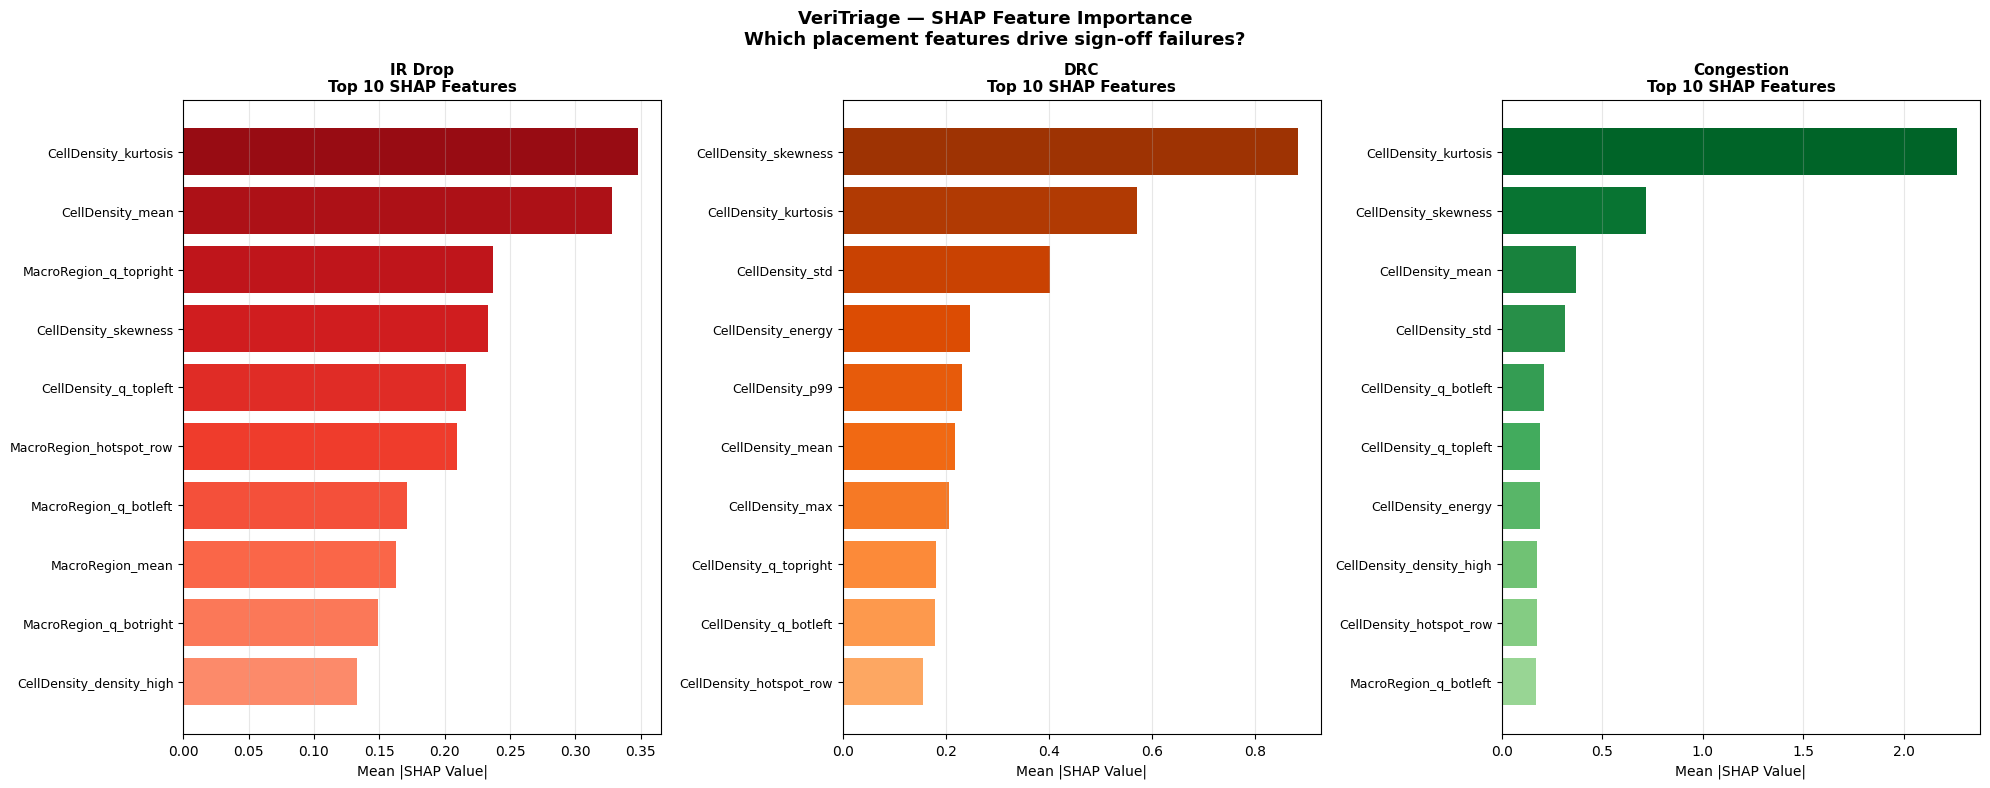

SHAP plot saved!


In [4]:
np.random.seed(42)
sample_idx = np.random.choice(len(X), 500, replace=False)
X_sample = X[sample_idx].astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
color_maps = ['Reds', 'Oranges', 'Greens']
shap_results = {}

for idx, (task, model) in enumerate(models.items()):
    print(f"Computing SHAP for {task}...")

    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap_results[task] = sv

    mean_shap   = np.abs(sv).mean(axis=0)
    top10_idx   = np.argsort(mean_shap)[-10:]
    top10_vals  = mean_shap[top10_idx]
    top10_names = [feature_names[i] for i in top10_idx]

    cmap = plt.cm.get_cmap(color_maps[idx])
    bar_colors = cmap(np.linspace(0.4, 0.9, 10))

    axes[idx].barh(range(10), top10_vals, color=bar_colors)
    axes[idx].set_yticks(range(10))
    axes[idx].set_yticklabels(top10_names, fontsize=9)
    axes[idx].set_xlabel('Mean |SHAP Value|', fontsize=10)
    axes[idx].set_title(f'{task}\nTop 10 SHAP Features',
                        fontsize=11, fontweight='bold')
    axes[idx].grid(axis='x', alpha=0.3)
    print(f"  Top feature: {top10_names[-1]}")

plt.suptitle('VeriTriage — SHAP Feature Importance\n'
             'Which placement features drive sign-off failures?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/05_shap_importance.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved!")

## 3. Single Chip Explanation — Waterfall Plot

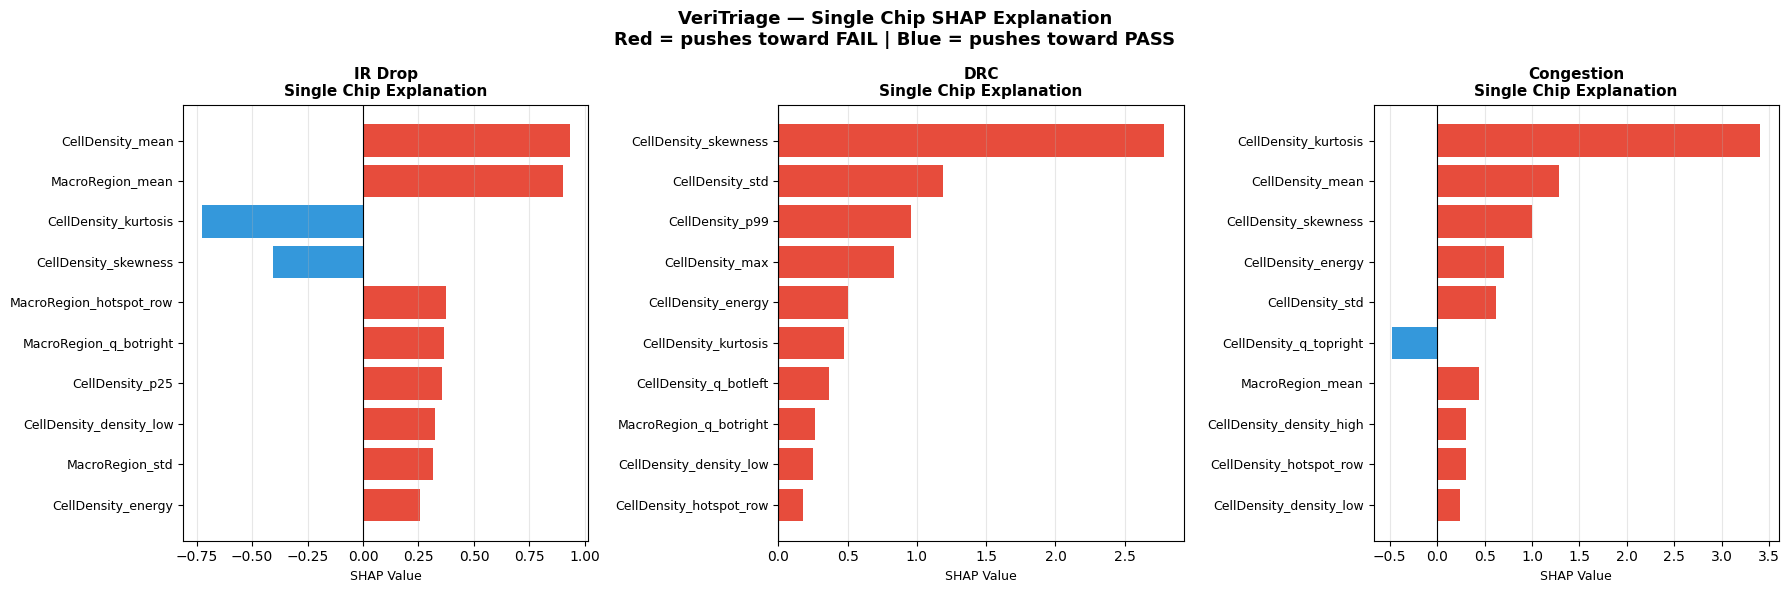

Waterfall plot saved!


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (task, sv) in enumerate(shap_results.items()):
    chip_idx   = np.abs(sv).sum(axis=1).argmax()
    chip_shap  = sv[chip_idx]

    top10_idx   = np.argsort(np.abs(chip_shap))[-10:]
    top10_shap  = chip_shap[top10_idx]
    top10_names = [feature_names[i] for i in top10_idx]
    bar_colors  = ['#e74c3c' if v > 0 else '#3498db' for v in top10_shap]

    axes[idx].barh(range(10), top10_shap, color=bar_colors)
    axes[idx].set_yticks(range(10))
    axes[idx].set_yticklabels(top10_names, fontsize=9)
    axes[idx].set_xlabel('SHAP Value', fontsize=9)
    axes[idx].set_title(f'{task}\nSingle Chip Explanation',
                        fontsize=11, fontweight='bold')
    axes[idx].axvline(0, color='black', linewidth=0.8)
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('VeriTriage — Single Chip SHAP Explanation\n'
             'Red = pushes toward FAIL | Blue = pushes toward PASS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / "results/plots/05_shap_waterfall.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall plot saved!")

## 5. Complete Results Summary

### Model Performance
| Task | Accuracy | F1 Score | ROC-AUC |
|------|----------|----------|---------|
| IR Drop | 85.1% | 0.821 | 0.924 |
| DRC | 83.2% | 0.826 | 0.915 |
| Congestion | 93.2% | 0.929 | 0.962 |

### SHAP Key Findings
| Task | Top Feature | Physical Meaning |
|------|-------------|-----------------|
| IR Drop | CellDensity_kurtosis | Extreme density variations cause power delivery failures |
| DRC | CellDensity_skewness | Asymmetric density distribution causes rule violations |
| Congestion | CellDensity_kurtosis | Peaked density distributions drive routing overflow |

### Chip Family Analysis
| Task | RISCY Fail Rate | zero-riscy Fail Rate | Gap |
|------|----------------|---------------------|-----|
| IR Drop | 47.0% | 37.2% | 9.8% |
| DRC | 56.9% | 35.2% | 21.7% |
| Congestion | 51.9% | 43.2% | 8.7% |

### Cross-Architecture Generalization Gap
| Task | Cross-family AUC | Mixed AUC | Drop |
|------|-----------------|-----------|------|
| IR Drop | 0.573 | 0.910 | 33.7% |
| DRC | 0.851 | 0.916 | 6.5% |
| Congestion | 0.935 | 0.962 | 2.8% |

### Key Contributions
1. **Multi-task triage** — first pipeline predicting IR drop + DRC + congestion simultaneously
2. **Architecture-aware** — RISCY chips fail DRC at 21.7% higher rate than zero-riscy
3. **Interpretable** — SHAP explains which placement features cause each failure
4. **Automated pipeline** — one function call produces full sign-off triage report
5. **Practical impact** — saves 33-100% of sign-off runtime per design iteration